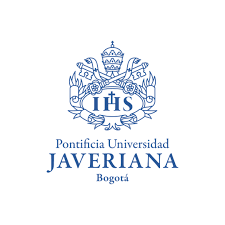

***Pontificia Universidad Javeriana***
# **Big Data Analysis**

### **Lab: Metrics and Machine Learning with PySpark**

Author: Sara Mejia Giraldo

Date: 28/04/2026

## **Methodology**

- Cargar Sesion Spark
- Cargar datos de Banca
- Limpiar Datos


# **1. Preparation**

## 1.1. Setting Up pip Environment Variables

In [1]:
## Import libraries that will be used
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Libraries for PySpark
from pylab import *

import findspark
findspark.init()

import pyspark.sql.functions as F
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, SparkSession, Row
from pyspark.sql.types import *

from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc

## 1.2. Initializing the Spark Session
Spark DataFrames were used as an optimized data structure that facilitates exploration, cleaning, transformation, and analysis tasks on large volumes of data efficiently, taking advantage of cluster resources and improving performance compared to traditional methods.

In [2]:
config = SparkConf()
config.set("spark.scheduler.mode", "FAIR")
config.set("spark.scheduler.allocation", "/Almacen/Spark/conf/fairscheduler.xml ")
config.setMaster("spark://10.43.97.171:7077")
config.setAppName("Banca_Mejia_Spark")

sparkMejia = SparkSession.builder.config(conf=config).getOrCreate()
SQLContext(sparkContext=sparkMejia.sparkContext, sparkSession=sparkMejia)
sparkContextoMejia = sparkMejia.sparkContext.getOrCreate()

sparkMejia

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/07 16:44:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## 1.3. Loading Data from Hadoop HDFS

Hadoop Distributed File System (HDFS) is Apache Hadoop’s distributed file system. It is designed to store large volumes of data across multiple machines in a cluster simultaneously. It stands out for its high fault tolerance and scalability.
Next, Apache Spark is used to read the CSV file stored in HDFS and load it into a Spark DataFrame.

In [3]:
!/mnt/sda1/Cluster/Hadoop/bin/hadoop fs -ls /csv
### we establish the dataset as a dataframe object 
df00 = sparkMejia.read.format("csv").option("header", "true").option("sep", ";").load("hdfs://10.195.34.34:9000/csv/bank-full.csv")

df00.show(5)

/bin/bash: line 1: /mnt/sda1/Cluster/Hadoop/bin/hadoop: No such file or directory


[Stage 1:>                                                          (0 + 1) / 1]

+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|         job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+------------+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 58|  management|married| tertiary|     no|   2143|    yes|  no|unknown|  5|  may|     261|       1|   -1|       0| unknown| no|
| 44|  technician| single|secondary|     no|     29|    yes|  no|unknown|  5|  may|     151|       1|   -1|       0| unknown| no|
| 33|entrepreneur|married|secondary|     no|      2|    yes| yes|unknown|  5|  may|      76|       1|   -1|       0| unknown| no|
| 47| blue-collar|married|  unknown|     no|   1506|    yes|  no|unknown|  5|  may|      92|       1|   -1|       0| unknown| no|
| 33|     unknown| single|  unknown|     no|      1|     no|  no|unknown|  5|  may|     19

# **2. Data Wrangling**

## 2.1. Understanding the variables (Columns)

In [4]:
df00.columns

['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

| Variable Name | Role | Type | Demographic | Description | Units | Missing Values |
|---|---|---|---|---|---|---|
| age | Feature | Integer | Age | Edad del cliente. |  | no |
| job | Feature | Categorical | Occupation | Tipo de trabajo: `admin.`, `blue-collar`, `entrepreneur`, `housemaid`, `management`, `retired`, `self-employed`, `services`, `student`, `technician`, `unemployed`, `unknown`. |  | no |
| marital | Feature | Categorical | Marital Status | Estado civil: `divorced`, `married`, `single`, `unknown`. Nota: `divorced` incluye personas divorciadas o viudas. |  | no |
| education | Feature | Categorical | Education Level | Nivel educativo: `basic.4y`, `basic.6y`, `basic.9y`, `high.school`, `illiterate`, `professional.course`, `university.degree`, `unknown`. |  | no |
| default | Feature | Binary |  | Indica si el cliente tiene crédito en mora/incumplimiento. |  | no |
| balance | Feature | Integer |  | Saldo promedio anual. | euros | no |
| housing | Feature | Binary |  | Indica si el cliente tiene crédito de vivienda. |  | no |
| loan | Feature | Binary |  | Indica si el cliente tiene préstamo personal. |  | no |
| contact | Feature | Categorical |  | Tipo de comunicación de contacto: `cellular`, `telephone`. |  | yes |
| day_of_week | Feature | Date |  | Día de la semana del último contacto. |  | no |
| month | Feature | Date |  | Mes del último contacto: `jan`, `feb`, `mar`, ..., `nov`, `dec`. |  | no |
| duration | Feature | Integer |  | Duración del último contacto, en segundos (númerica). Nota: esta variable afecta directamente la variable target (y), puesto que si la duracion es 0 entonces y=no. Por lo tanto, este dato solo debe incluirse con fines comparativos y debe descartarse si la intención es obtener un modelo predictivo realista.|  | no |
| campaign | Feature | Integer |  | Cantidad de contactos durante esta campaña, para este cliente |  | no |
| pdays | Feature | Integer |  | Cantidad de dias que pasaron desde que el cliente fue contactado por ultima vez. (Un valor de -1 indica que el cliente no fue contactado previamente) |  | yes |
| previous | Feature | Integer |  | Cantidad de contactos hechos antes de esta campaña, para este cliente |  | no |
| poutcome | Feature | Integer |  | Resultado de la campaña de marketing previa: `failure`, `nonexistent`, `success` |  | yes |
| y | Target | Binary |  | El cliente se ha suscrito a un deposito a plazo |  | yes |

#### Suggestions:
- One of the goals of this analysis is to build a predictive model, that is why the variable `duration` should be deleted.

## 2.2. Data Types: Consistency and Transformations
To ensure the quality and consistency of the dataset, a review and adjustment of the data types for each variable was carried out.

In [5]:
### show the quantity of data
data_quantity = df00.count()
print("Data quantity:", data_quantity)

[Stage 2:=============================>                             (1 + 1) / 2]

Data quantity: 45211


### 2.2.1. Initial Structure Review

Using Apache Spark’s printSchema() function, the initial schema of the DataFrame was inspected. During this first validation, it was identified that all columns had been loaded as string type.

In [6]:
df00.printSchema()

root
 |-- age: string (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: string (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: string (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: string (nullable = true)
 |-- campaign: string (nullable = true)
 |-- pdays: string (nullable = true)
 |-- previous: string (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### COMMENTS:
- All the variables are set as string
- The datatype of the following variables has to be changed from string to integer:
    - `age`, `balance`, `duration`, `campaign`, `pdays`, `previous`
- The last column, named y, is the target variable. The one that we want to predict

### 2.2.2. Definition of expected data types

#### COMMENTS:
- The process for consistently transforming numeric data is shown.
- Keep in mind that visualization using a pandas DataFrame should be used for small objects.

### 2.2.3. Variable transformation
The name of the TARGET variable was changed from y to term_deposit. Then, the casting or data type conversion process was applied, assigning each column the corresponding format. This allowed the database to be prepared for statistical analysis, numerical calculations, and later validations, avoiding errors caused by working with numeric variables as text.

In [7]:
# casting from string to integer
df01 = df00.withColumn("age", df00.age.cast("int"))
df01 = df01.withColumn("balance", df01.balance.cast("int"))
df01 = df01.withColumn("day", df01.day.cast("int"))
df01 = df01.withColumn("duration", df01.duration.cast("int"))
df01 = df01.withColumn("campaign", df01.campaign.cast("int"))
df01 = df01.withColumn("pdays", df01.pdays.cast("int"))
df01 = df01.withColumn("previous", df01.previous.cast("int"))

In [8]:
# name change
df02 = df01.withColumnRenamed('y', 'term_deposit')

### 2.3. Null Data Visualization

In [9]:
df02.select([F.count(F.when(F.isnan(c) | F.col(c).isNull(), c)).alias(c) for c in df02.columns]).show()

[Stage 5:=============================>                             (1 + 1) / 2]

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|term_deposit|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|           0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+------------+



#### COMMENTS:
A visualization of missing values was performed to identify possible null or incomplete data within the dataset. After the analysis, no null values were found in any of the variables, indicating that the dataset is complete and does not require missing data treatment.

### 2.4. Descriptive statistics
A visualization of missing values was performed to identify possible null or incomplete data within the dataset. After the analysis, no null values were found in any of the variables, indicating that the dataset is complete and does not require missing data treatment.

In [11]:
# Reviewed the dataset to see if it is bias
total = df02.count()
df_Y = df02. groupBy("term_deposit").count()
auxPD = df_Y.withColumn("Percentage", df_Y["count"]*100/total)
auxPD.show()

[Stage 14:=============================>                            (1 + 1) / 2]

+------------+-----+------------------+
|term_deposit|count|        Percentage|
+------------+-----+------------------+
|          no|39922| 88.30151954170445|
|         yes| 5289|11.698480458295547|
+------------+-----+------------------+



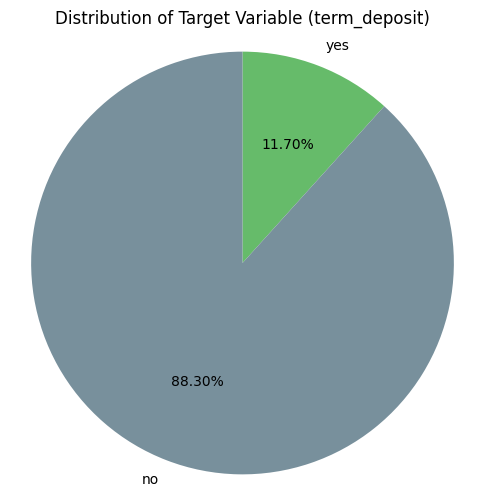

In [12]:
# convert the auxPD dataset from PySpak to Pandas
auxPD_pandas = auxPD.toPandas()

auxPD_pandas["term_deposit"] = auxPD_pandas["term_deposit"].astype(str)
auxPD_pandas = auxPD_pandas.set_index("term_deposit").loc[["yes", "no"]].reset_index()

# Set colors
colores = ["#66BB6A", "#78909C"]  # yes = green, no = gray

plt.figure(figsize=(6, 6))

plt.pie(auxPD_pandas["count"],labels=auxPD_pandas["term_deposit"],autopct="%1.2f%%",startangle=90,colors=colores,counterclock=False)

plt.title("Distribution of Target Variable (term_deposit)")
plt.axis("equal")
plt.show()

#### Bias Observations:
There is a bias in the dataset since almost 90% of the records in the target variable (term_deposit) correspond to "No". 
- The minority class is "Yes", representing 11% with 5,289 records.
- The majority class is "No", representing 88% with 39,922 records.
- The variable is binary, and it is important to avoid introducing additional bias when training predictive models.

#### Recommendations
The distribution of the target variable shows a possible class imbalance. This is important because if one class has a much higher frequency than the other, the predictive model may tend to classify most cases into the dominant class. Therefore, in later stages, evaluating the model only with accuracy will not be sufficient, since this metric can give a misleading impression of model performance.

- Instead, it is recommended to use metrics such as precision, recall, F1-score, confusion matrix, and AUC.
- Additionally, balancing strategies or the use of class weights during training should be considered.

In [13]:
df02.describe().toPandas()

26/05/07 16:49:44 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
                                                                                

,summary,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,term_deposit
0,count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
1,mean,40.93621021432837,None,None,None,None,1362.2720576850766,None,None,None,15.80641879188693,None,258.1630797814691,2.763840658246887,40.19782796222158,0.5803233726305546,None,None
2,stddev,10.618762040975401,None,None,None,None,3044.7658291685243,None,None,None,8.322476153044589,None,257.5278122651712,3.0980208832791813,100.12874599059818,2.3034410449312164,None,None
3,min,18,admin.,divorced,primary,no,-8019,no,no,cellular,1,apr,0,1,-1,0,failure,no
4,max,95,unknown,single,unknown,yes,102127,yes,yes,unknown,31,sep,4918,63,871,275,unknown,yes


#### ***It is necessary to review the categorical variables***

In [15]:
col_cat=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'term_deposit']
#Se agrupa y se observa cada categoria
for col in col_cat:
    df02.groupBy(col).count().show()

+-------------+-----+
|          job|count|
+-------------+-----+
|   management| 9458|
|      retired| 2264|
|      unknown|  288|
|self-employed| 1579|
|      student|  938|
|  blue-collar| 9732|
| entrepreneur| 1487|
|       admin.| 5171|
|   technician| 7597|
|     services| 4154|
|    housemaid| 1240|
|   unemployed| 1303|
+-------------+-----+

+--------+-----+
| marital|count|
+--------+-----+
|divorced| 5207|
| married|27214|
|  single|12790|
+--------+-----+

+---------+-----+
|education|count|
+---------+-----+
|  unknown| 1857|
| tertiary|13301|
|secondary|23202|
|  primary| 6851|
+---------+-----+

+-------+-----+
|default|count|
+-------+-----+
|     no|44396|
|    yes|  815|
+-------+-----+

+-------+-----+
|housing|count|
+-------+-----+
|     no|20081|
|    yes|25130|
+-------+-----+

+----+-----+
|loan|count|
+----+-----+
|  no|37967|
| yes| 7244|
+----+-----+

+---------+-----+
|  contact|count|
+---------+-----+
|  unknown|13020|
| cellular|29285|
|telephone| 2906|
+

# **3. Exploratory Data Analysis (EDA)**

In [16]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

## 3.1. Parameter Distribution

### 3.1.1. Age Distribution

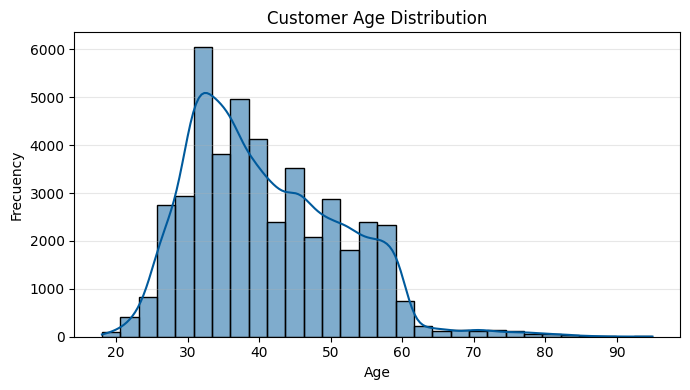

In [18]:
age_pd = df02.select("age").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=age_pd,x="age",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("Age")
plt.title("Customer Age Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/1325750943.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=age_y_pd,x="term_deposit",y="age",order=["yes", "no"],


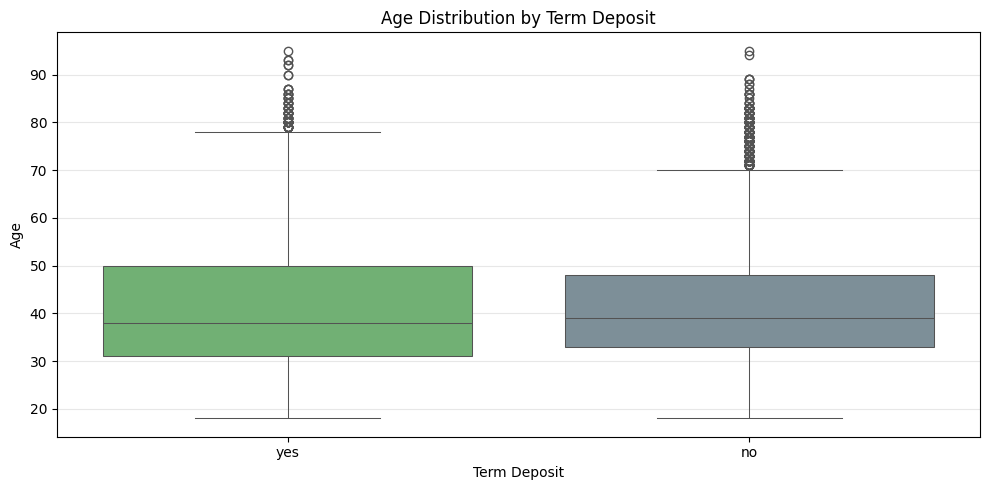

In [21]:
age_y_pd = df02.select("age", "term_deposit").toPandas()
age_y_pd["term_deposit"] = age_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))
sns.boxplot(data=age_y_pd,x="term_deposit",y="age",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Age")
plt.xlabel("Term Deposit")
plt.title("Age Distribution by Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### OBSERVACIONES:
- La edad se distribuye entre 30 y 50 años. Desues de los 70 años se empiezan a encontrar los outliers.

### 3.1.2. Balance Distribution

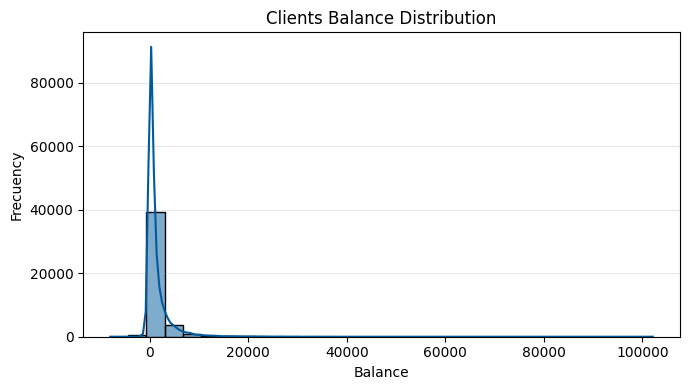

In [23]:
balance_pd = df02.select("balance").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=balance_pd,x="balance",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("Balance")
plt.title("Clients Balance Distribution")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/4093068498.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=balance_y_pd,x="term_deposit",y="balance",order=["yes", "no"],


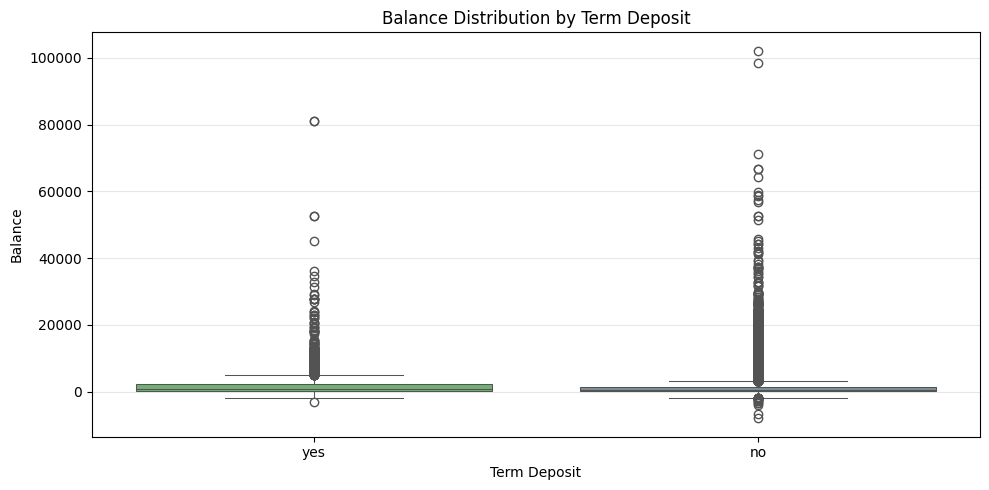

In [25]:
balance_y_pd = df02.select("balance", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
balance_y_pd["term_deposit"] = balance_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=balance_y_pd,x="term_deposit",y="balance",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Balance")
plt.xlabel("Term Deposit")
plt.title("Balance Distribution by Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.3. Day Distribution

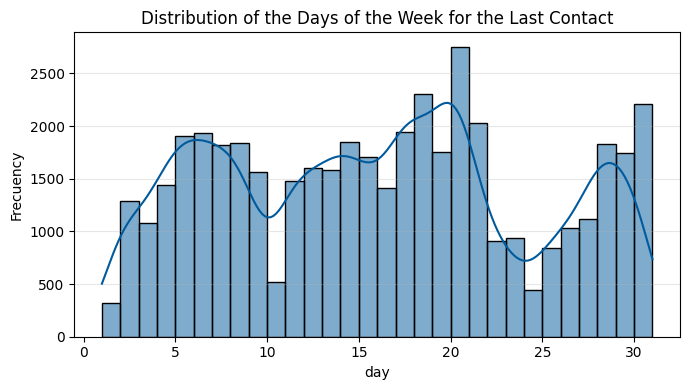

In [26]:
day_pd = df02.select("day").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=day_pd,x="day",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("day")
plt.title("Distribution of the Days of the Week for the Last Contact")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/3946913528.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_y_pd,x="term_deposit",y="day",order=["yes", "no"],


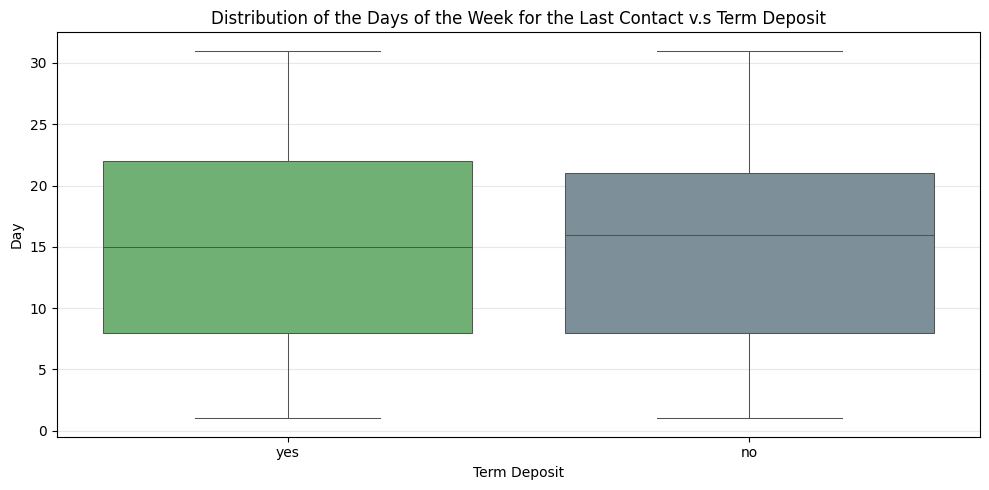

In [27]:
day_y_pd = df02.select("day", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = day_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=day_y_pd,x="term_deposit",y="day",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Day")
plt.xlabel("Term Deposit")
plt.title("Distribution of the Days of the Week for the Last Contact v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.4. Duration Distribution

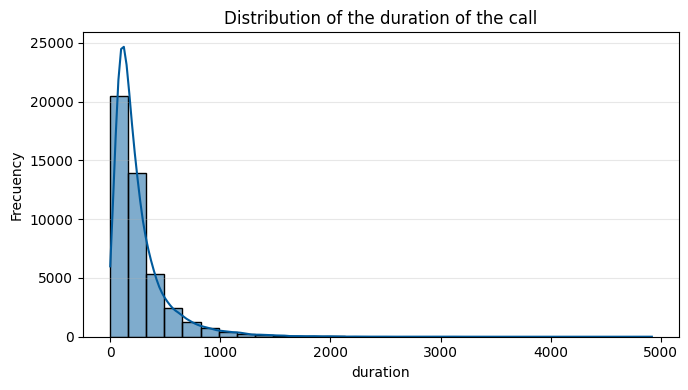

In [28]:
duration_pd = df02.select("duration").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=duration_pd,x="duration",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("duration")
plt.title("Distribution of the duration of the call")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/4212349537.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=duration_y_pd,x="term_deposit",y="duration",order=["yes", "no"],


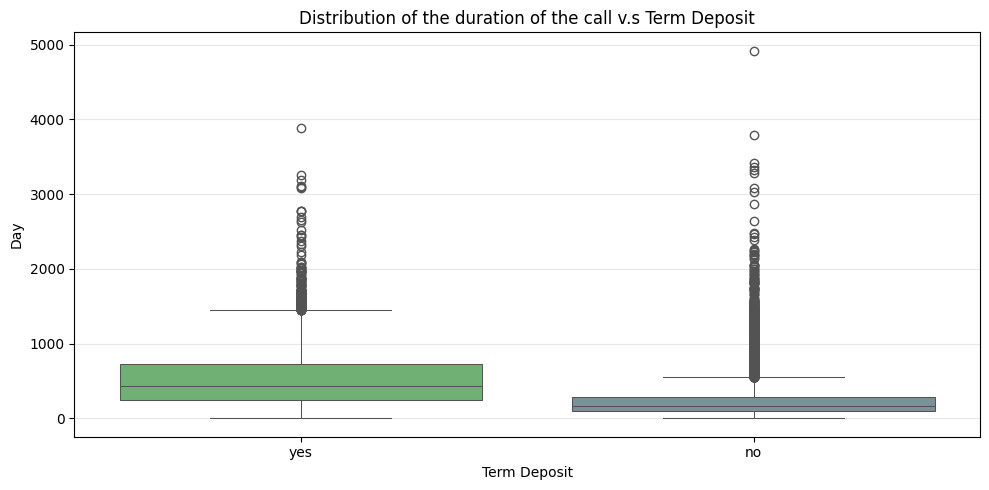

In [30]:
duration_y_pd = df02.select("duration", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = duration_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=duration_y_pd,x="term_deposit",y="duration",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("Day")
plt.xlabel("Term Deposit")
plt.title("Distribution of the duration of the call v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.5. Campaign Distribution

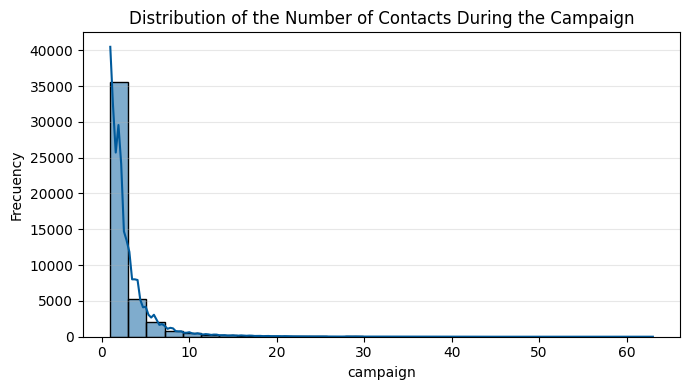

In [31]:
campaign_pd = df02.select("campaign").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=campaign_pd,x="campaign",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("campaign")
plt.title("Distribution of the Number of Contacts During the Campaign")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/2550810183.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=campaign_y_pd,x="term_deposit",y="campaign",order=["yes", "no"],


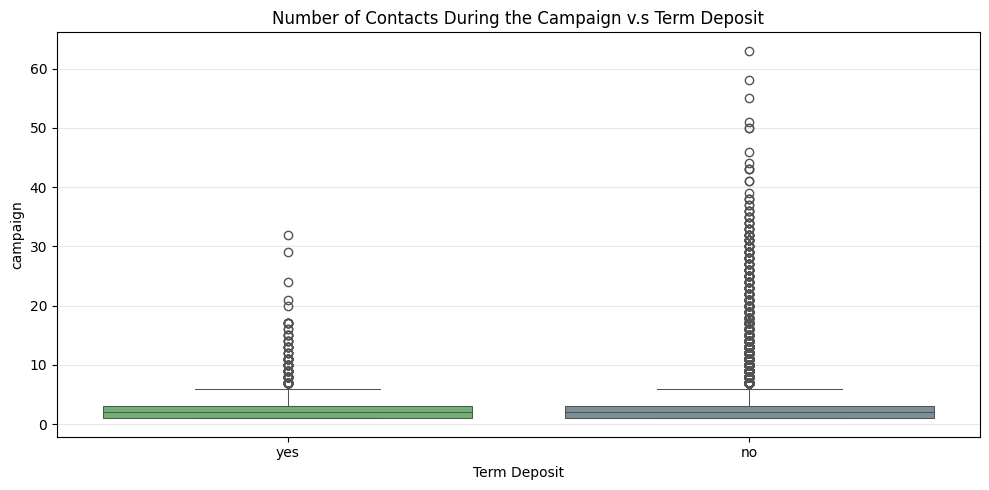

In [32]:
campaign_y_pd = df02.select("campaign", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = campaign_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=campaign_y_pd,x="term_deposit",y="campaign",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("campaign")
plt.xlabel("Term Deposit")
plt.title("Number of Contacts During the Campaign v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

More contacts can affect the answer of the customer about the term deposit, more contacts tend to be NO.

### 3.1.6. Pdays Distribution 

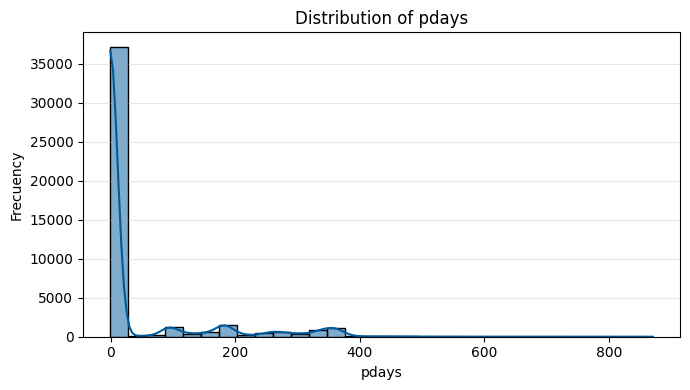

In [33]:
pdays_pd = df02.select("pdays").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=pdays_pd,x="pdays",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("pdays")
plt.title("Distribution of pdays")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/2050968714.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pdays_y_pd,x="term_deposit",y="pdays",order=["yes", "no"],


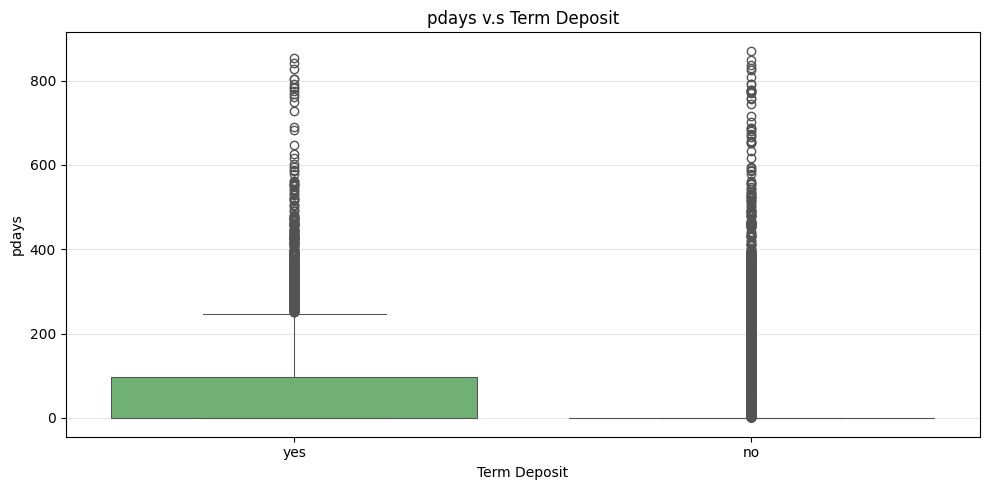

In [34]:
pdays_y_pd = df02.select("pdays", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = pdays_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=pdays_y_pd,x="term_deposit",y="pdays",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("pdays")
plt.xlabel("Term Deposit")
plt.title("pdays v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1.7. Previous Distribution 

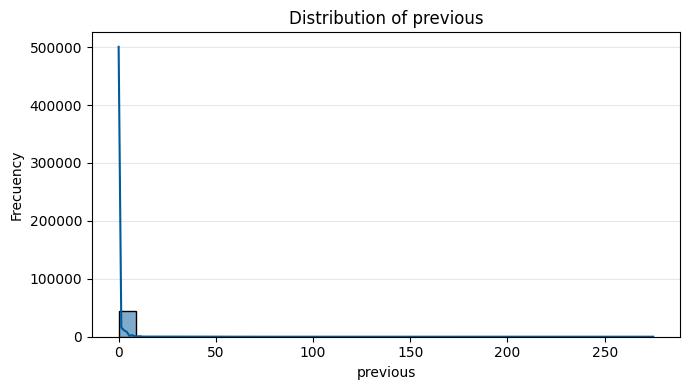

In [35]:
previous_pd = df02.select("previous").toPandas()

plt.figure(figsize=(7, 4))

sns.histplot(data=previous_pd,x="previous",bins=30,kde=True,color="#005A9C")

plt.ylabel("Frecuency")
plt.xlabel("previous")
plt.title("Distribution of previous")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_103338/3750700691.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],


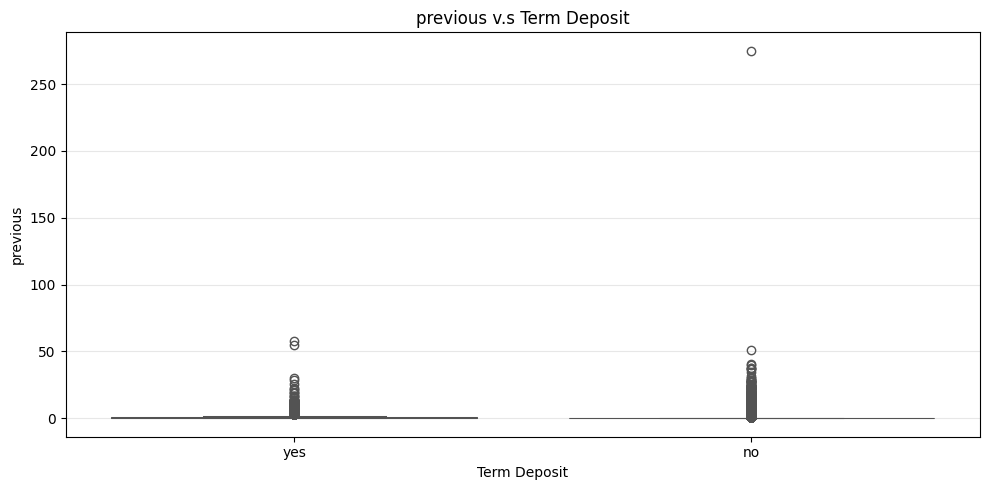

In [36]:
previous_y_pd = df02.select("previous", "term_deposit").toPandas()

# Ordenar las categorías para que salga primero yes y luego no
day_y_pd["term_deposit"] = previous_y_pd["term_deposit"].astype(str)

plt.figure(figsize=(10, 5))

sns.boxplot(data=previous_y_pd,x="term_deposit",y="previous",order=["yes", "no"],
    palette={
        "yes": "#66BB6A",
        "no": "#78909C"
    },
    linewidth=0.75
)

plt.ylabel("previous")
plt.xlabel("Term Deposit")
plt.title("previous v.s Term Deposit")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 3.2. Correlation

- Recordar porque Duration aunque muestra una alta correlacion se deberia eliminar
- pday y previous pueden influir a favor, tambien se tiene que tener en cuenta los boxplots
- campaign tiene una influencia negativa


In [23]:
colINT=['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

In [46]:
dfauxNum = df01.select(colINT+['y'])
dfauxNum = dfauxNum.withColumn('y', F.when(dfauxNum['y'] == "yes",1).otherwise(0))
dfauxNum.show(5)

+---+-------+---+--------+--------+-----+--------+---+
|age|balance|day|duration|campaign|pdays|previous|  y|
+---+-------+---+--------+--------+-----+--------+---+
| 58|   2143|  5|     261|       1|   -1|       0|  0|
| 44|     29|  5|     151|       1|   -1|       0|  0|
| 33|      2|  5|      76|       1|   -1|       0|  0|
| 47|   1506|  5|      92|       1|   -1|       0|  0|
| 33|      1|  5|     198|       1|   -1|       0|  0|
+---+-------+---+--------+--------+-----+--------+---+
only showing top 5 rows



In [47]:
# we change the auxiliar dataframe into a VectorAssembler of 'feature'
# take into account that the variable 'y' was incorporated with the numeric variables in order to create the vector
# the idea is to create the correlation matrix with the vector so that the variables are normalized
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.stat import Correlation

assembler = VectorAssembler(inputCols=dfauxNum.columns, outputCol='features')
#normalized and scalated
dfNumVector = assembler.transform(dfauxNum).select('features')


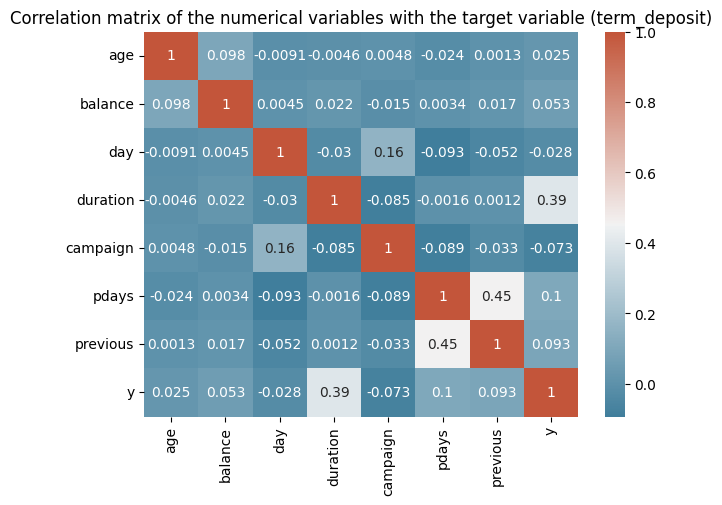

In [52]:
matrixCorr = Correlation.corr(dfNumVector, 'features').head()
vectorCorr = matrixCorr[0].toArray()
dfCorrelation = pd.DataFrame(vectorCorr, columns=dfauxNum.columns, index=dfauxNum.columns)

# generate a custom diverging colormap
cmapMejia = sns.diverging_palette(230, 20, as_cmap=True)

plt.figure(figsize=(7,5))
sns.heatmap(dfCorrelation, annot=True, cmap=cmapMejia)
plt.title("Correlation matrix of the numerical variables with the target variable (term_deposit)")
plt.show()

#### Comments:
- In general, most of the variables seem to be independant, with little correlation.
- Duration has to be deleted
- pdday and previous have a low correlation between them, it is related with...

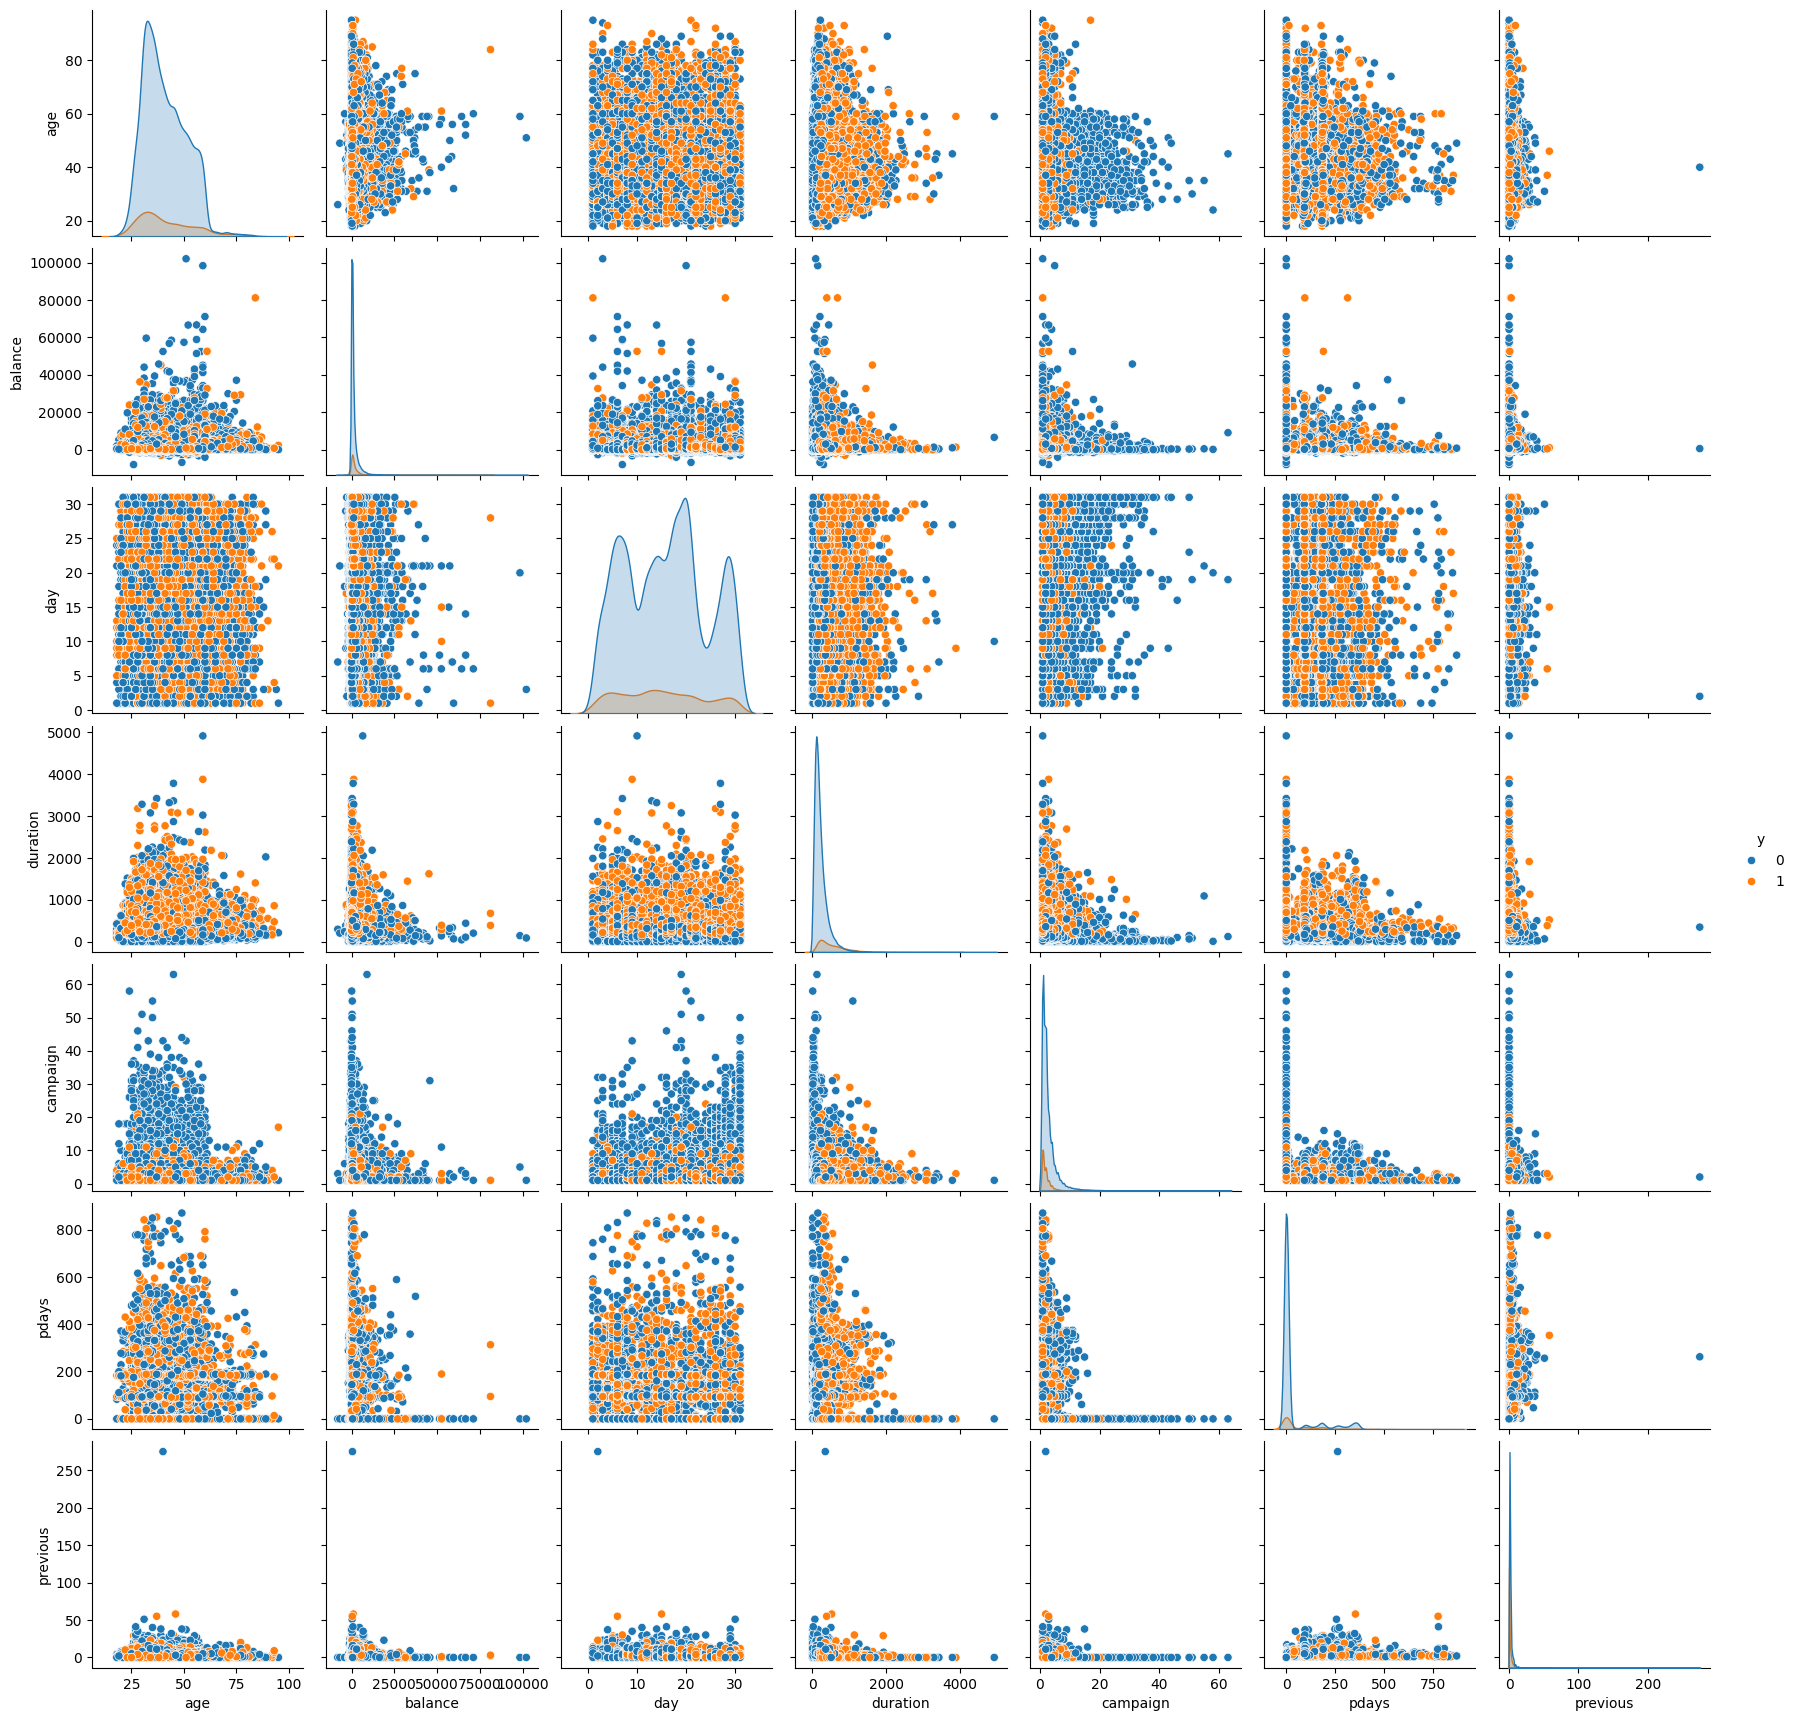

In [56]:
sns.pairplot(dfauxNum.toPandas(), kind='scatter', hue='y')
plt.show()